<div style="text-align: center; line-height: 1.5;">

<h2>UNIVERSITY OF SÃO PAULO (USP)</h2>

<p>
Escola Politécnica<br>
Escola de Engenharia de São Carlos
</p>

</div>

<hr>

<p>
<b>Course:</b> Introduction to Machine Learning Applications for Sustainability Research<br>
<b>Assignment:</b> Lecture 4 – KNN, Naive Bayes & Model Evaluation<br>
<b>Professors:</b> Lucas Zanon and Tiago Sigahi<br>
<b>Students:</b> Bheatriz Nogueira<br>
<b>Date:</b> July 17, 2026
</p>

<hr>

# Task 1 - Load the data, avoid leakage and choose predictors

--- Top 10 Correlated Indicators ---
sdg1_lmicpov     -0.775213
sdg6_sanita       0.720236
sdg3_neonat      -0.700726
sdg7_cleanfuel    0.686405
sdg6_safewat      0.682855
sdg3_lifee        0.677619
sdg1_wpc         -0.675287
sdg4_second       0.672507
sdg7_elecac       0.667337
sdg6_water        0.654281
dtype: float64


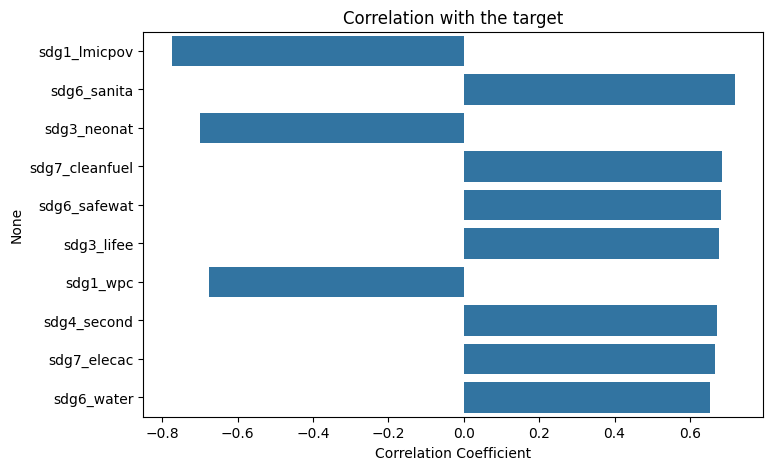

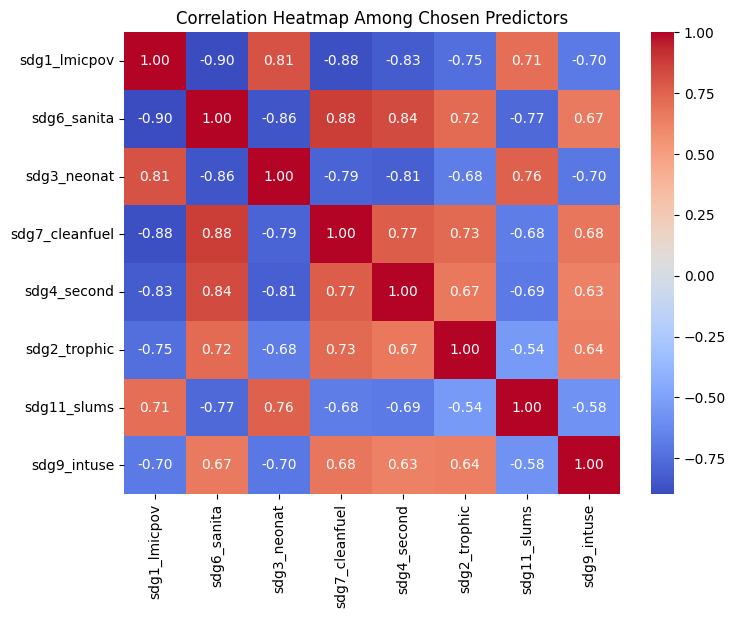

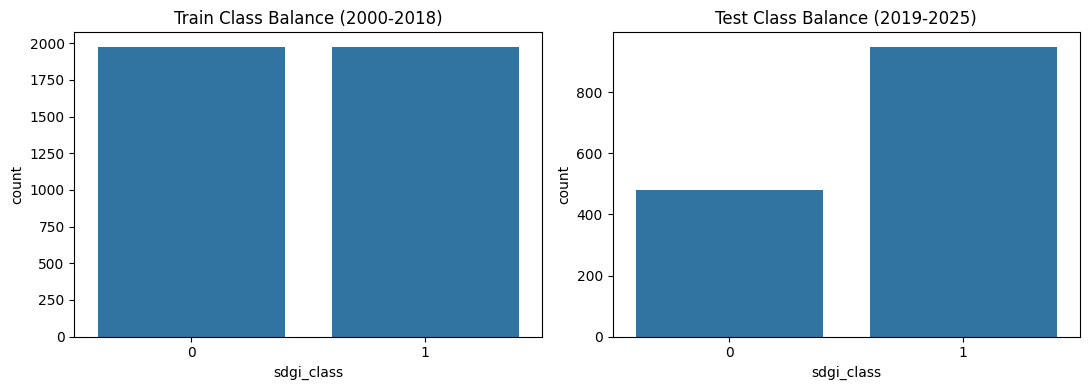

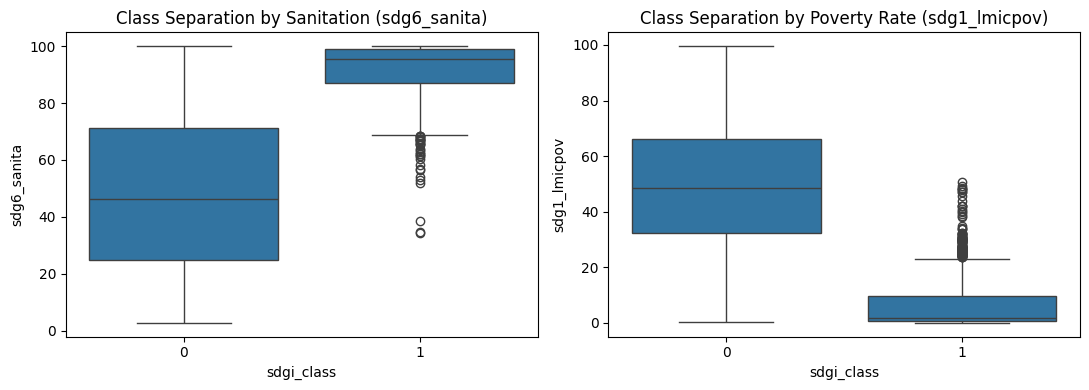

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# DATA LOADING & CORRELATION ANALYSIS (Avoiding Data Leakage)
FILE = "sdgi_classification_dataset.xlsx"
train_raw = pd.read_excel(FILE, sheet_name=0)  # Training period 2000-2018
test_raw = pd.read_excel(FILE, sheet_name=1)   # Testing period 2019-2025

TARGET = "sdgi_class"

# Correlation with the target -- note we drop the leaking column sdgi_s
num = train_raw.select_dtypes("number").drop(columns=[TARGET, "sdgi_s", "year"], errors="ignore")
corr = num.corrwith(train_raw[TARGET]).sort_values(key=abs, ascending=False)

print("--- Top 10 Correlated Indicators ---")
print(corr.head(10))

# Plotting correlation with target
plt.figure(figsize=(8, 5))
sns.barplot(x=corr.head(10).values, y=corr.head(10).index)
plt.title("Correlation with the target")
plt.xlabel("Correlation Coefficient")
plt.show()

# PREDICTOR CORRELATION ANALYSIS (Multicollinearity Check)
predictors = ["sdg1_lmicpov", "sdg6_sanita", "sdg3_neonat", "sdg7_cleanfuel",
              "sdg4_second", "sdg2_trophic", "sdg11_slums", "sdg9_intuse"]

plt.figure(figsize=(8, 6))
sns.heatmap(train_raw[predictors].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap Among Chosen Predictors")
plt.show()

# CLASS BALANCE: TRAIN VS TEST
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x=train_raw[TARGET], ax=ax[0])
ax[0].set_title("Train Class Balance (2000-2018)")
ax[0].set_xlabel("sdgi_class")

sns.countplot(x=test_raw[TARGET], ax=ax[1])
ax[1].set_title("Test Class Balance (2019-2025)")
ax[1].set_xlabel("sdgi_class")
plt.tight_layout()
plt.show()

# CLASS SEPARATION: BOXPLOTS FOR STRONG PREDICTORS
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(data=train_raw, x=TARGET, y="sdg6_sanita", ax=ax[0])
ax[0].set_title("Class Separation by Sanitation (sdg6_sanita)")

sns.boxplot(data=train_raw, x=TARGET, y="sdg1_lmicpov", ax=ax[1])
ax[1].set_title("Class Separation by Poverty Rate (sdg1_lmicpov)")
plt.tight_layout()
plt.show()

### Predictor selection

We selected the predictors using two simple criteria: their correlation with the target and the representation of different SDGs.

We kept `sdg1_lmicpov`, `sdg6_sanita`, `sdg3_neonat`, and `sdg7_cleanfuel` because they had the strongest absolute correlations with `sdgi_class`. We also selected `sdg4_second`, `sdg2_trophic`, `sdg11_slums`, and `sdg9_intuse`. These indicators still had relevant correlations with the target and added information about education, food consumption patterns, urban conditions and digital access.

The heatmap shows that some predictors are still strongly correlated. This is reasonable because different dimensions of sustainable development are connected. Our selection did not remove all correlation, but it reduced the repetition of indicators from the same SDG and created a more diverse set of predictors.

### Answer

The indicators that separate high- from low-SDG country-years most strongly are `sdg1_lmicpov`, `sdg6_sanita`, and `sdg3_neonat`. Lower poverty and neonatal mortality are associated with the high-SDG class, while better sanitation is positively associated with it. The boxplots also show a clear separation between the two classes for poverty and sanitation.

We must remove `sdgi_s` because `sdgi_class` was created directly from this continuous SDG Index. Therefore, `sdgi_s` already contains the information needed to determine the target class. Using it as a predictor would cause data leakage, allowing the model to indirectly access the correct answer instead of learning meaningful relationships from the individual SDG indicators.

In [ ]:
# Quick check to see the exact column names available in your dataset
print("Available columns in training dataset:")
print([col for col in train_raw.columns if "sdg" in col])

Available columns in training dataset:
['sdg1_wpc', 'sdg1_lmicpov', 'sdg2_undernsh', 'sdg2_obesity', 'sdg2_trophic', 'sdg2_crlyld', 'sdg2_snmi', 'sdg3_matmort', 'sdg3_neonat', 'sdg3_u5mort', 'sdg3_tb', 'sdg3_hiv', 'sdg3_ncds', 'sdg3_traffic', 'sdg3_lifee', 'sdg3_fertility', 'sdg3_vac', 'sdg4_primary', 'sdg4_second', 'sdg5_familypl', 'sdg5_edat', 'sdg5_lfpr', 'sdg5_parl', 'sdg6_water', 'sdg6_sanita', 'sdg6_freshwat', 'sdg6_scarcew', 'sdg6_safewat', 'sdg6_safesan', 'sdg7_elecac', 'sdg7_cleanfuel', 'sdg7_co2twh', 'sdg7_renewcon', 'sdg9_intuse', 'sdg9_mobuse', 'sdg9_articles', 'sdg9_patents', 'sdg11_slums', 'sdg11_pm25', 'sdg11_pipedwat', 'sdg12_pollprod', 'sdg12_pollimp', 'sdg12_nprod', 'sdg12_nimport', 'sdg13_co2gcp', 'sdg13_ghgimport', 'sdg14_cpma', 'sdg14_discard', 'sdg15_cpta', 'sdg15_cpfa', 'sdg15_redlist', 'sdg16_homicides', 'sdg17_govex', 'sdgi_s', 'sdgi_class']


### Your turn

Because the test set contains more class 1 observations than class 0 observations, a model could obtain relatively high accuracy simply by predicting the majority class most of the time. This would not necessarily mean that the model identifies both classes well. Therefore, we should also examine precision, recall, F1-score, and the confusion matrix to understand how well the model predicts high- and low-SDG country-years.

# Task 2 - Preprocess the data

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Defining the diverse set of predictors chosen in Task 1
predictors = ["sdg1_lmicpov", "sdg6_sanita", "sdg3_neonat", "sdg7_cleanfuel",
              "sdg4_second", "sdg2_trophic", "sdg11_slums", "sdg9_intuse"]

# Fitting the imputer and scaler ONLY on the training data to avoid leakage
imputer = SimpleImputer(strategy="median").fit(train_raw[predictors])
scaler  = StandardScaler().fit(imputer.transform(train_raw[predictors]))

# Transforming both train and test sheets
X_train = scaler.transform(imputer.transform(train_raw[predictors]))
X_test  = scaler.transform(imputer.transform(test_raw[predictors]))
y_train = train_raw[TARGET]
y_test  = test_raw[TARGET]

print("X_train:", X_train.shape, "| X_test:", X_test.shape)

X_train: (3952, 8) | X_test: (1430, 8)


### Answer

We fit the imputer and scaler only on the training data to prevent information from the test set from influencing the model. If we used the test data to calculate the median or the scaling parameters, we would introduce data leakage and obtain an overly optimistic evaluation.

KNN needs scaled features because it classifies observations based on distances. Without scaling, variables with larger numerical ranges would dominate the distance calculation, even if they were not more important. Standardization puts the predictors on a comparable scale so that each one contributes more fairly to the KNN classification.

### Your turn

Testing on future years is fair because it reproduces the real prediction situation: we train the model using information available from past years and then evaluate it on data that the model has never seen. This prevents future information from influencing the training process and provides a more honest estimate of how well the model can predict new country-years.

# Task 3 - KNN classification

In [ ]:

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_auc_score

# Loop suggested by the professor to evaluate different K values
print("--- Evaluating K-NN for different K values ---")
for k in [5, 15, 25]:
    m = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
    p = m.predict(X_test)
    print("k =", k, "-> accuracy =", round(accuracy_score(y_test, p), 3),
          " F1 =", round(f1_score(y_test, p), 3))

print("\n--- Final KNN Model (K=25) Evaluation ---")
# Fitting the final model using K=25 because it achieved the highest accuracy and F1-score among the tested values
knn = KNeighborsClassifier(n_neighbors=25).fit(X_train, y_train)
y_pred  = knn.predict(X_test)
y_proba = knn.predict_proba(X_test)[:, 1]   # probability of class 1, for the ROC curve

# Generating the evaluation metrics required by the Task context
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print(f"AUC-ROC Score: {roc_auc_score(y_test, y_proba):.4f}")

# Calculating the baseline accuracy for the "Your turn" task
baseline_accuracy = (y_test == 1).mean()
print(f"\nBaseline Accuracy (Always predicting Class 1): {round(baseline_accuracy, 3)}")



--- Evaluating K-NN for different K values ---
k = 5 -> accuracy = 0.864  F1 = 0.892
k = 15 -> accuracy = 0.878  F1 = 0.906
k = 25 -> accuracy = 0.903  F1 = 0.929

--- Final KNN Model (K=25) Evaluation ---
Confusion Matrix:
[[387  94]
 [ 44 905]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.80      0.85       481
           1       0.91      0.95      0.93       949

    accuracy                           0.90      1430
   macro avg       0.90      0.88      0.89      1430
weighted avg       0.90      0.90      0.90      1430

AUC-ROC Score: 0.9539

Baseline Accuracy (Always predicting Class 1): 0.664


### Answer

Accuracy increases as K increases. It is 0.864 for K = 5, 0.878 for K = 15, and 0.903 for K = 25. The F1-score also increases from 0.892 to 0.929. Therefore, among the three values compared in this exercise, K = 25 achieved the best observed performance.

We used K = 25 for the following evaluation because it had the highest accuracy and F1-score among the tested values. However, in a more complete study, K should be selected using a validation set or cross-validation instead of the final test set.

The KNN model with K = 25 clearly outperforms the majority-class baseline of approximately 66%. Its accuracy of 90.3% is substantially higher, and its F1-score of 0.929 indicates a good balance between precision and recall.

### Your turn

In [ ]:
baseline_accuracy = (y_test == 1).mean()
print("Class 1 observations:", (y_test == 1).sum())
print("Total observations:", len(y_test))
print("Baseline accuracy:", round(baseline_accuracy, 3))

Class 1 observations: 949
Total observations: 1430
Baseline accuracy: 0.664


By always predicting class 1, we obtain a baseline accuracy of 0.664, or 66.4%. The KNN model with K = 25 achieves an accuracy of 0.903, or 90.3%, which is 23.9 percentage points higher than the baseline.

Therefore, the KNN model clearly performs better than simply predicting the majority class. However, because the test set is imbalanced, we should also examine precision, recall, F1-score, the confusion matrix, and AUC instead of relying only on accuracy.

# Task 4 - Evaluate the model

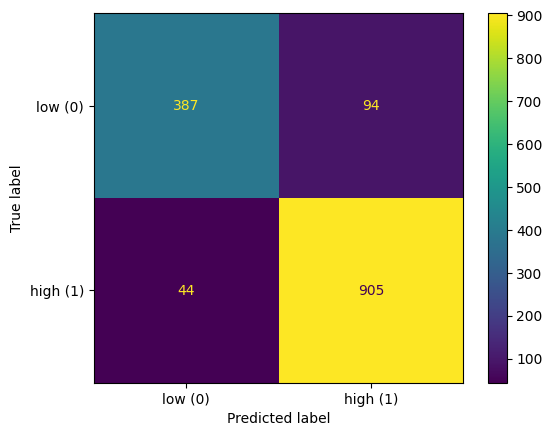

Accuracy : 0.903
Precision: 0.906
Recall   : 0.954
F1-score : 0.929


In [ ]:
# Import evaluation metrics and display tools from sklearn
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, roc_auc_score, roc_curve, accuracy_score, f1_score)
import matplotlib.pyplot as plt

# Generate the confusion matrix using true labels and model predictions
cm = confusion_matrix(y_test, y_pred)

# Configure and plot the confusion matrix with custom labels
ConfusionMatrixDisplay(cm, display_labels=["low (0)", "high (1)"]).plot()
plt.show()

# Print the standard classification performance metrics rounded to 3 decimal places
print("Accuracy :", round(accuracy_score(y_test, y_pred), 3))
print("Precision:", round(precision_score(y_test, y_pred), 3))
print("Recall   :", round(recall_score(y_test, y_pred), 3))
print("F1-score :", round(f1_score(y_test, y_pred), 3))

### Answer

The confusion matrix shows 94 false positives and 44 false negatives. This means that 94 low-SDG country-years were incorrectly classified as high-SDG, while 44 high-SDG country-years were incorrectly classified as low-SDG.

Precision is 0.906, meaning that 90.6% of the country-years predicted as high-SDG were actually high-SDG. Recall is 0.954, meaning that the model correctly identified 95.4% of all truly high-SDG country-years.

AUC is useful because it evaluates how well the model separates the two classes across different classification thresholds, rather than considering only one fixed threshold. The AUC of 0.954 indicates that the model has a strong ability to distinguish between low- and high-SDG country-years.


### Your turn

Manual precision: 0.906
Manual recall   : 0.954


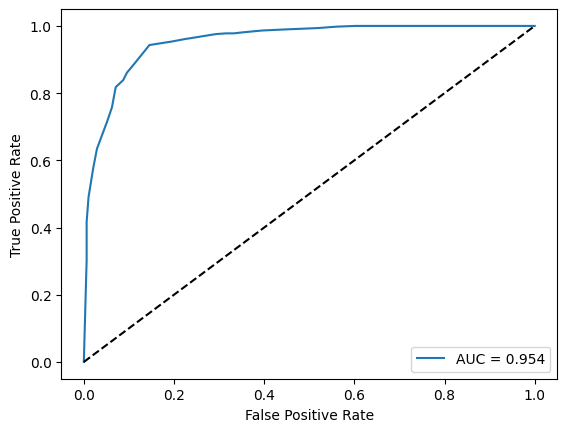

In [ ]:
TP = 905
FP = 94
FN = 44

precision_manual = TP / (TP + FP)
recall_manual = TP / (TP + FN)

print("Manual precision:", round(precision_manual, 3))
print("Manual recall   :", round(recall_manual, 3))
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.plot(fpr, tpr, label="AUC = %.3f" % roc_auc_score(y_test, y_proba))
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

Using the confusion matrix, we have TP = 905, FP = 94, and FN = 44.

Precision = TP / (TP + FP) = 905 / (905 + 94) = 905 / 999 = 0.906.

Recall = TP / (TP + FN) = 905 / (905 + 44) = 905 / 949 = 0.954.

These values match the precision and recall printed by sklearn.

# Task 5 - Naive Bayes classification

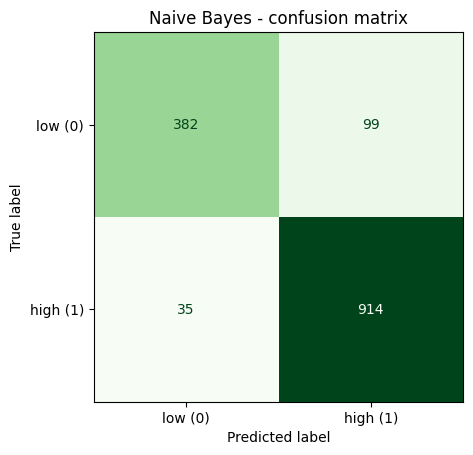

Accuracy : 0.906
Precision: 0.902
Recall   : 0.963
F1-score : 0.932
AUC      : 0.929


In [ ]:
# Import the Gaussian Naive Bayes classifier model
from sklearn.naive_bayes import GaussianNB

# Initialize and train the Gaussian Naive Bayes model on the training data
nb = GaussianNB().fit(X_train, y_train)

# Generate class predictions for the test dataset
y_pred_nb  = nb.predict(X_test)

# Extract predicted probabilities for Class 1 to build the ROC curve
y_proba_nb = nb.predict_proba(X_test)[:, 1]

# Compute the confusion matrix using true target labels and Naive Bayes predictions
cm_nb = confusion_matrix(y_test, y_pred_nb)

# Display the confusion matrix graphically with a green color map and a title
ConfusionMatrixDisplay(cm_nb, display_labels=["low (0)", "high (1)"]).plot(cmap="Greens", colorbar=False)
plt.title("Naive Bayes - confusion matrix"); plt.show()

# Print the final classification evaluation metrics rounded to 3 decimal places
print("Accuracy :", round(accuracy_score(y_test, y_pred_nb), 3))
print("Precision:", round(precision_score(y_test, y_pred_nb), 3))
print("Recall   :", round(recall_score(y_test, y_pred_nb), 3))
print("F1-score :", round(f1_score(y_test, y_pred_nb), 3))
print("AUC      :", round(roc_auc_score(y_test, y_proba_nb), 3))

### Answer

The two models produced very similar results. Naive Bayes achieved slightly higher accuracy (0.906 versus 0.903), recall (0.963 versus 0.954), and F1-score (0.932 versus 0.929). KNN achieved slightly higher precision (0.906 versus 0.902) and a higher AUC (0.954 versus 0.929).

Naive Bayes makes slightly more false alarms than KNN: it has 99 false positives, compared with 94 for KNN. KNN makes more misses of class 1: it has 44 false negatives, compared with 35 for Naive Bayes.

In this classification, a false positive means that a low-SDG country-year is incorrectly classified as high-SDG. Therefore, a struggling country could be overlooked. If missing a struggling country is considered worse, we would prefer KNN because it has fewer false positives.

### Your turn
The independence assumption is not completely realistic for these SDG indicators. The heatmap shows strong correlations between several predictors, especially poverty, sanitation, neonatal mortality, clean fuel, and education.

Because Naive Bayes treats the predictors as independent, it may count related information more than once. This can affect its predicted probabilities and lead to some classification errors. However, the model still achieved good results in this dataset.


# Task 6 - Compare the models

In [ ]:
# The commented section below shows a template dictionary with the hardcoded results
#results = pd.DataFrame({
    #"Model":     ["KNN", "Naive Bayes"],
    #"Accuracy":  [0.903, 0.906],
    #"Precision": [0.906, 0.902],
    #"Recall":    [0.954, 0.963],
    #"F1":        [0.929, 0.932],
    #"AUC":       [0.954, 0.929],})

#results

# Calculate and store performance metrics for the K-Nearest Neighbors model
acc_knn = accuracy_score(y_test, y_pred)
prec_knn = precision_score(y_test, y_pred)
rec_knn = recall_score(y_test, y_pred)
f1_knn = f1_score(y_test, y_pred)
auc_knn = roc_auc_score(y_test, y_proba)

# Calculate and store performance metrics for the Naive Bayes model
acc_nb = accuracy_score(y_test, y_pred_nb)
prec_nb = precision_score(y_test, y_pred_nb)
rec_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)
auc_nb = roc_auc_score(y_test, y_proba_nb)

# Construct a comprehensive comparison DataFrame using the calculated metrics
results = pd.DataFrame({
    "Model": ["KNN", "Naive Bayes"],
    "Accuracy": [acc_knn, acc_nb],
    "Precision": [prec_knn, prec_nb],
    "Recall": [rec_knn, rec_nb],
    "F1": [f1_knn, f1_nb],
    "AUC": [auc_knn, auc_nb]
})

# Display the final comparison table rounded to three decimal places
results.round(3)


,Model,Accuracy,Precision,Recall,F1,AUC
0,KNN,0.903,0.906,0.954,0.929,0.954
1,Naive Bayes,0.906,0.902,0.963,0.932,0.929


### Answer
Overall, we would choose Naive Bayes for this task because it achieved slightly higher accuracy (0.906), recall (0.963), and F1-score (0.932). Its higher recall means that it missed fewer truly high-SDG observations.

However, the two models performed very similarly at the default classification threshold. KNN had slightly higher precision and a notably higher AUC (0.954 versus 0.929), indicating a better ability to distinguish between the two classes across different classification thresholds.

On this imbalanced test set, accuracy alone may hide differences in how the models treat each class. Precision measures the reliability of the high-SDG predictions, recall measures how many truly high-SDG observations are identified, and AUC evaluates class separation across different thresholds. Therefore, these metrics provide a more complete evaluation than accuracy alone.

### Your turn
We would report recall because the decision-maker wants to identify as many high-performing countries as possible. Recall measures the proportion of truly high-SDG country-years correctly identified by the model. Naive Bayes achieved the highest recall, 0.963, meaning that it identified 96.3% of the truly high-SDG observations, compared with 95.4% for KNN. Therefore, Naive Bayes would be preferred for this objective.

### Additional model comparison

As an additional analysis, we generated classification reports and plotted the ROC curves of both models together. We used the same predictors, preprocessing steps, and final KNN model adopted in the previous tasks. This comparison provides more detail about the performance of each model for both classes.


 EVALUATION REPORT - KNN (K=25)
Confusion Matrix:
[[387  94]
 [ 44 905]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.80      0.85       481
           1       0.91      0.95      0.93       949

    accuracy                           0.90      1430
   macro avg       0.90      0.88      0.89      1430
weighted avg       0.90      0.90      0.90      1430

AUC-ROC Score: 0.9539

 EVALUATION REPORT - Naive Bayes
Confusion Matrix:
[[382  99]
 [ 35 914]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.79      0.85       481
           1       0.90      0.96      0.93       949

    accuracy                           0.91      1430
   macro avg       0.91      0.88      0.89      1430
weighted avg       0.91      0.91      0.90      1430

AUC-ROC Score: 0.9293


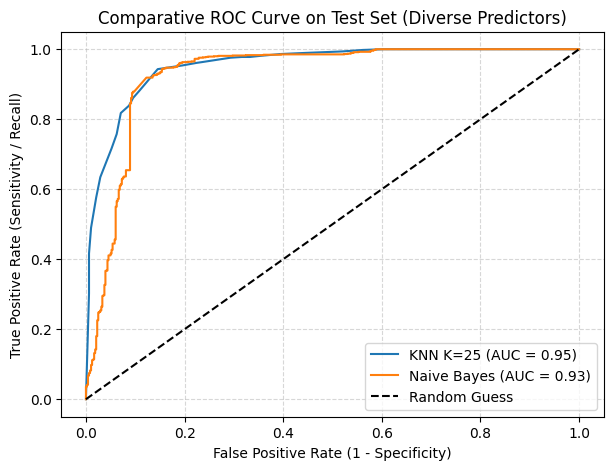

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# DATA PREPROCESSING (Using the new diverse set of predictors)
# Updating the features list to match your text selection exactly
updated_predictors = [
    "sdg1_lmicpov", "sdg6_sanita", "sdg3_neonat", "sdg7_cleanfuel",
    "sdg4_second", "sdg2_trophic", "sdg11_slums", "sdg9_intuse"
]

X_train_raw = train_raw[updated_predictors]
y_train = train_raw[TARGET]
X_test_raw = test_raw[updated_predictors]
y_test = test_raw[TARGET]

# 1. Handling missing values using median imputation
imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train_raw)
X_test_imp = imputer.transform(X_test_raw)

# 2. Feature Scaling (Standardization to give equal weight to all indicators)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled = scaler.transform(X_test_imp)

# MODEL 1: K-NEAREST NEIGHBORS (KNN)
knn = KNeighborsClassifier(n_neighbors=25)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
y_prob_knn = knn.predict_proba(X_test_scaled)[:, 1]

# MODEL 2: NAIVE BAYES (Gaussian)
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)
y_pred_nb = nb.predict(X_test_scaled)
y_prob_nb = nb.predict_proba(X_test_scaled)[:, 1]

# EVALUATION METRICS GENERATION
def display_metrics(model_name, y_true, y_pred, y_prob):
    print(f"\n======================================")
    print(f" EVALUATION REPORT - {model_name}")
    print(f"======================================")
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))
    print(f"AUC-ROC Score: {roc_auc_score(y_true, y_prob):.4f}")

display_metrics("KNN (K=25)", y_test, y_pred_knn, y_prob_knn)
display_metrics("Naive Bayes", y_test, y_pred_nb, y_prob_nb)

# VISUALIZATION: COMPARATIVE ROC CURVE
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)

plt.figure(figsize=(7, 5))
plt.plot(fpr_knn, tpr_knn, label=f'KNN K=25 (AUC = {roc_auc_score(y_test, y_prob_knn):.2f})')
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC = {roc_auc_score(y_test, y_prob_nb):.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.title('Comparative ROC Curve on Test Set (Diverse Predictors)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Reflection questions

**1- Explain data leakage in your own words, using sdgi_s as the example.**

Data leakage occurs when a model uses information that directly or indirectly contains the answer it is supposed to predict. In this dataset, sdgi_class is calculated from sdgi_s. Therefore, including sdgi_s as a predictor would allow the model to reconstruct the target and achieve unrealistically high performance instead of learning meaningful relationships from the individual SDG indicators.

**2- Why can accuracy alone be misleading on an imbalanced test set? What do precision, recall and F1 add?**

Accuracy can be misleading because a model may achieve a high score simply by predicting the majority class most of the time. Precision measures the reliability of positive predictions, recall measures how many actual positive observations are detected, and F1-score combines precision and recall into a single measure. Together, these metrics provide a more complete evaluation of model performance.

**3- KNN vs Naive Bayes: give one advantage of each.**

One advantage of KNN is that it does not require strong assumptions about the statistical distribution of the data and can learn complex local patterns. One advantage of Naive Bayes is that it is fast and simple, and it achieved slightly higher recall in our results. However, its independence assumption may be unrealistic when the predictors are strongly correlated.
